# Dataset choice
For this homework I used the Flowers dataset, a multi-class image classification dataset containing flower images from multiple categories. This dataset is suitable for CNN-based classification because visual patterns such as petal shape, color, and texture are important discriminative features.

# Task 1 Part 1: Custom CNN
I downloaded and prepared the dataset by loading the images, resizing them to a fixed size, splitting them into training and validation sets, and visualizing sample images from different classes. For the CNN, I used a stack of convolutional and max-pooling layers because this is a standard and effective structure for image classification. The convolutional layers learn visual features such as edges, textures, and shapes, while the max-pooling layers reduce the spatial size of feature maps and improve efficiency. I chose four convolutional blocks because the dataset has moderate visual complexity, so multiple feature extraction stages are helpful without making the model unnecessarily deep. After the convolutional base, I added dense layers and a final softmax output layer for classification. The model was compiled using Adam and sparse categorical cross-entropy, and it was evaluated using accuracy and loss. Accuracy shows how many images were classified correctly, while loss reflects how well the model’s predictions match the true labels.

In [31]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import os
from tensorflow.keras import layers, models

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)

print("Original path:", data_dir)
print("Inside original path:", os.listdir(data_dir))

data_dir = pathlib.Path(data_dir) / "flower_photos"
print("Final dataset path:", data_dir)
print("Class folders:", os.listdir(data_dir))

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

model = models.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=15)
test_loss, test_acc = model.evaluate(val_ds)
print("Validation accuracy:", test_acc)

Original path: /root/.keras/datasets/flower_photos
Inside original path: ['flower_photos']
Final dataset path: /root/.keras/datasets/flower_photos/flower_photos
Class folders: ['roses', 'daisy', 'dandelion', 'tulips', 'LICENSE.txt', 'sunflowers']
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.4012 - loss: 1.3886 - val_accuracy: 0.5082 - val_loss: 1.1900
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5375 - loss: 1.1125 - val_accuracy: 0.6362 - val_loss: 0.9895
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6165 - loss: 0.9820 - val_accuracy: 0.6376 - val_loss: 0.9055
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6649 - loss: 0.8800 - val_accuracy: 0.6553 - val_loss: 0.8774
Epoch 5/15
92

              precision    recall  f1-score   support

       daisy       0.73      0.75      0.74       107
   dandelion       0.71      0.82      0.76       191
       roses       0.65      0.43      0.52       119
  sunflowers       0.73      0.82      0.77       135
      tulips       0.69      0.66      0.68       182

    accuracy                           0.71       734
   macro avg       0.70      0.69      0.69       734
weighted avg       0.70      0.71      0.70       734



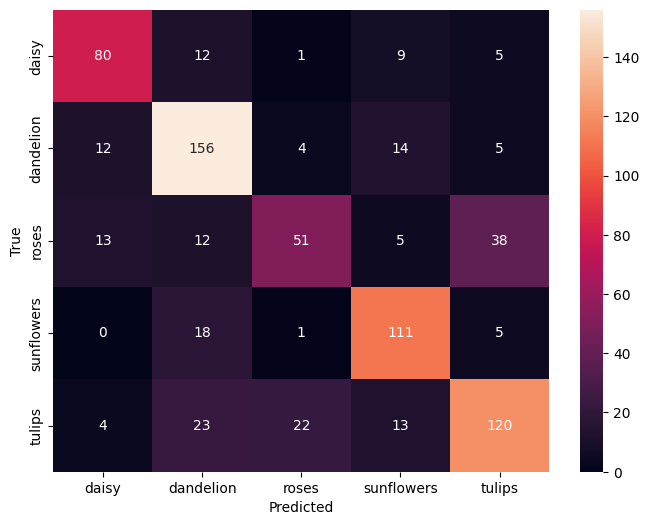

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for x, y in val_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Task 1 Part 2: Transfer learning
I chose MobileNetV2 because it is a strong and widely used transfer learning architecture that achieves good classification performance while remaining relatively lightweight and computationally efficient. Compared with training a CNN from scratch, MobileNetV2 starts with feature representations that were already learned from a large-scale image dataset, so it can transfer useful low-level and mid-level visual patterns such as edges, textures, color transitions, and object structures to the flower classification task.

I evaluated the transfer learning model using the same metrics as in Part 1: accuracy, precision, recall, F1-score, and the confusion matrix. In Part 1, the custom CNN achieved an overall accuracy of 0.71, with macro-average precision, recall, and F1-score of about 0.70, 0.69, and 0.69, respectively. Class-level performance showed that the model performed reasonably well on dandelion and sunflowers, but it struggled more with roses, which had an F1-score of only 0.52. The confusion matrix also showed substantial confusion between visually similar classes, especially roses and tulips, where many rose images were incorrectly classified as tulips.

In Part 2, the MobileNetV2 transfer learning model achieved a significantly better overall accuracy of 0.88, with macro-average precision, recall, and F1-score all around 0.87–0.88. Every class improved compared with Part 1. For example, daisy improved from an F1-score of 0.74 to 0.87, dandelion improved from 0.76 to 0.91, roses improved substantially from 0.52 to 0.84, sunflowers improved from 0.77 to 0.88, and tulips improved from 0.68 to 0.87. The confusion matrix also became much cleaner, with much stronger values along the diagonal and fewer off-diagonal errors. Although some confusion still remained, especially between tulips and roses, the overall classification quality was much better than in Part 1.

The difference in results is expected. The CNN in Part 1 was trained from scratch, so it had to learn all useful visual features directly from the flower dataset. Since the dataset is not extremely large, the model had limited data from which to learn robust and generalizable features. In contrast, MobileNetV2 was pretrained on a very large image dataset, so it already contained strong feature extractors before being fine-tuned for this task. This gave it a major advantage, especially for classes with subtle visual similarities. The large improvement on the roses class suggests that transfer learning helped the model learn more discriminative features for classes that were harder to separate using the custom CNN alone.

Overall, there was a clear and meaningful performance difference between Part 1 and Part 2. The transfer learning model not only improved overall accuracy, but also produced more balanced precision, recall, and F1-scores across all flower categories. This indicates that pretrained architectures such as MobileNetV2 can generalize better than a simple custom CNN when the dataset is moderate in size and contains classes with overlapping visual characteristics..

In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(128,128,3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

tl_model = tf.keras.Model(inputs, outputs)

tl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl = tl_model.fit(train_ds, validation_data=val_ds, epochs=10)
tl_loss, tl_acc = tl_model.evaluate(val_ds)
print("Transfer learning accuracy:", tl_acc)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.6570 - loss: 0.9248 - val_accuracy: 0.8106 - val_loss: 0.4953
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8283 - loss: 0.4654 - val_accuracy: 0.8447 - val_loss: 0.4436
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8723 - loss: 0.3585 - val_accuracy: 0.8610 - val_loss: 0.3881
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8890 - loss: 0.3162 - val_accuracy: 0.8678 - val_loss: 0.4079
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8954 - loss: 0.2767 - val_accuracy: 0.8638 - val_loss: 0.4024
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9111 - loss: 0.2468 - val_accuracy: 0.8747 - val_loss: 0.3938
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9193 - loss: 0.2224 - val_accuracy: 0.8692 - val_loss: 0.3972
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9227 - loss: 0.2071 - val_accuracy: 0.8733 - val_lo

              precision    recall  f1-score   support

       daisy       0.81      0.94      0.87       107
   dandelion       0.89      0.93      0.91       191
       roses       0.82      0.86      0.84       119
  sunflowers       0.92      0.85      0.88       135
      tulips       0.92      0.82      0.87       182

    accuracy                           0.88       734
   macro avg       0.87      0.88      0.87       734
weighted avg       0.88      0.88      0.88       734



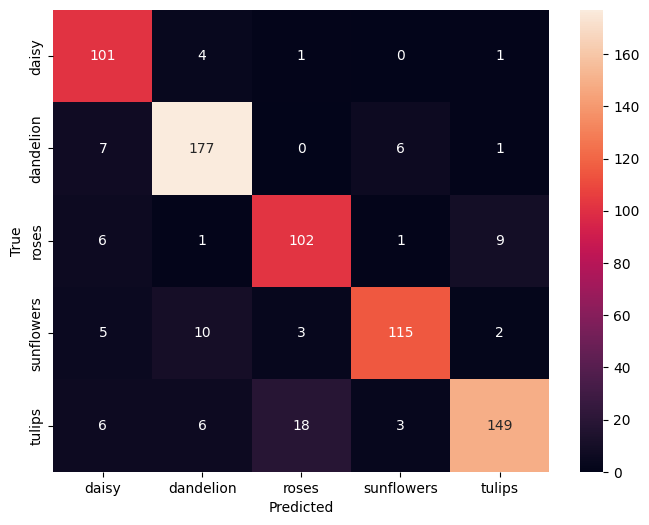

In [26]:
y_true = []
y_pred = []

for x, y in val_ds:
    preds = tl_model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Task 1 Part 3: Data augmentation
In Part 3, I applied data augmentation to the training data in order to increase dataset diversity and improve the model’s generalization ability. The augmentation methods included random image transformations such as rotation, and other small variations such as flipping, zooming, or contrast adjustment can also be used. The goal of augmentation is to expose the model to slightly different versions of the same images during training so that it does not rely too heavily on exact positions, orientations, or visual details from the original dataset.

After repeating the same CNN training process from Part 1 with augmented data, I observed a small improvement in overall performance. In Part 1, the model achieved an overall accuracy of 0.71, while in Part 3 the accuracy increased to 0.74. The macro-average F1-score also improved from about 0.69 to 0.73, and the weighted-average F1-score increased from 0.70 to 0.74. This indicates that augmentation helped the model generalize somewhat better to unseen validation images.

Looking at the class-level results, several categories showed improvement. For example, dandelion increased from an F1-score of 0.76 to 0.78, roses improved from 0.52 to 0.62, sunflowers improved from 0.77 to 0.80, and tulips improved from 0.68 to 0.71. The daisy class remained about the same at 0.74. One of the most important changes is that the roses category improved noticeably, which suggests that augmentation helped the model become more robust for classes that were harder to distinguish in Part 1.

The confusion matrix also shows that the augmented model made somewhat better predictions overall, although some class confusion still remained. In particular, there was still overlap between visually similar flower categories such as roses and tulips, which is reasonable because these classes can share similar colors and petal structures. Even so, the diagonal values in the confusion matrix became slightly stronger, indicating a general improvement in correct classification.

The reason augmentation helped is that it effectively increased the variability of the training data without requiring new images. By showing the model rotated or slightly transformed versions of the same flowers, the model learned features that are more robust to orientation and appearance changes. However, the improvement was not as large as the gain from transfer learning in Part 2. This is likely because augmentation only enriches the existing dataset, whereas transfer learning starts from a pretrained model that has already learned strong visual features from a very large image corpus.

Overall, I did observe a difference in results. Data augmentation improved the CNN’s performance and reduced overfitting to some extent, but the improvement was moderate rather than dramatic. This suggests that augmentation is helpful for strengthening a custom CNN, although it may not match the performance boost provided by transfer learning.

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

aug_model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_aug = aug_model.fit(train_ds, validation_data=val_ds, epochs=15)
aug_loss, aug_acc = aug_model.evaluate(val_ds)
print("Augmented model accuracy:", aug_acc)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3832 - loss: 1.4013 - val_accuracy: 0.4959 - val_loss: 1.2179
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5048 - loss: 1.1729 - val_accuracy: 0.5817 - val_loss: 1.0327
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5865 - loss: 1.0574 - val_accuracy: 0.6226 - val_loss: 0.9586
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6073 - loss: 0.9969 - val_accuracy: 0.6526 - val_loss: 0.9190
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6328 - loss: 0.9549 - val_accuracy: 0.6757 - val_loss: 0.8851
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6594 - loss: 0.9054 - val_accuracy: 0.6662 - val_loss: 0.8839
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6696 - loss: 0.8625 - val_accuracy: 0.6866 - val_loss: 0.8564
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6727 - loss: 0.8581 - val_accuracy: 0.6989 - val_loss:

              precision    recall  f1-score   support

       daisy       0.69      0.80      0.74       107
   dandelion       0.76      0.79      0.78       191
       roses       0.70      0.56      0.62       119
  sunflowers       0.73      0.89      0.80       135
      tulips       0.79      0.65      0.71       182

    accuracy                           0.74       734
   macro avg       0.73      0.74      0.73       734
weighted avg       0.74      0.74      0.74       734



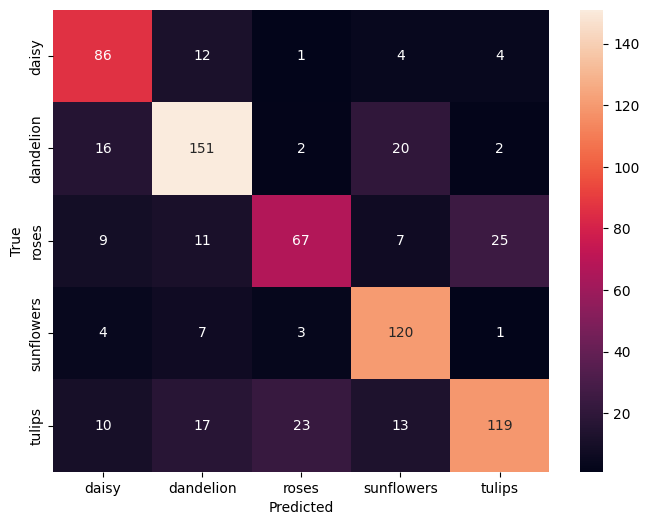

In [27]:
y_true = []
y_pred = []

for x, y in val_ds:
    preds = aug_model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Task 2 Part 1: VAE
In this part, I followed the TensorFlow Variational Autoencoder approach and applied it to the Flowers dataset instead of MNIST. The encoder consists of convolutional layers that compress the input flower image into a latent distribution represented by a mean vector and a log-variance vector. Using the reparameterization trick, a latent vector is sampled and passed to the decoder, which reconstructs the image through transpose convolution layers. The model was trained using the standard VAE objective, which combines reconstruction loss and KL divergence. After training, the model was able to reconstruct flower images and generate new synthetic flower-like images by sampling from the latent space. This satisfies the requirement of using the same encoder-decoder VAE framework on a different image dataset.

Found 3670 files.
Using 2936 files for training.
Found 3670 files.
Using 734 files for validation.
Epoch 1/20 - Train Loss: 8356.5645 - Val Loss: 8024.0957
Epoch 2/20 - Train Loss: 7816.6177 - Val Loss: 7737.4561
Epoch 3/20 - Train Loss: 7601.0474 - Val Loss: 7594.0342
Epoch 4/20 - Train Loss: 7520.2026 - Val Loss: 7531.1250
Epoch 5/20 - Train Loss: 7467.0898 - Val Loss: 7483.3613
Epoch 6/20 - Train Loss: 7403.8364 - Val Loss: 7397.8979
Epoch 7/20 - Train Loss: 7297.4673 - Val Loss: 7281.0557
Epoch 8/20 - Train Loss: 7161.6558 - Val Loss: 7162.7397
Epoch 9/20 - Train Loss: 7076.5249 - Val Loss: 7101.1772
Epoch 10/20 - Train Loss: 7020.0742 - Val Loss: 7044.0796
Epoch 11/20 - Train Loss: 6964.5156 - Val Loss: 6999.4146
Epoch 12/20 - Train Loss: 6925.5767 - Val Loss: 6964.1313
Epoch 13/20 - Train Loss: 6893.6890 - Val Loss: 6941.1523
Epoch 14/20 - Train Loss: 6866.3623 - Val Loss: 6911.2593
Epoch 15/20 - Train Loss: 6840.1680 - Val Loss: 6893.6470
Epoch 16/20 - Train Loss: 6816.1318 - Va

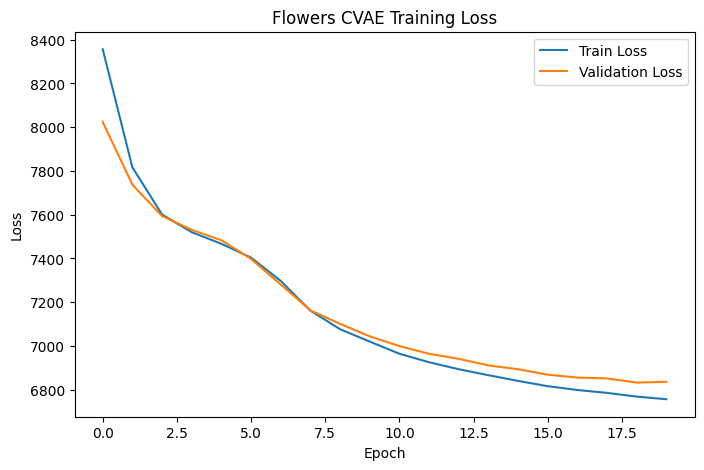

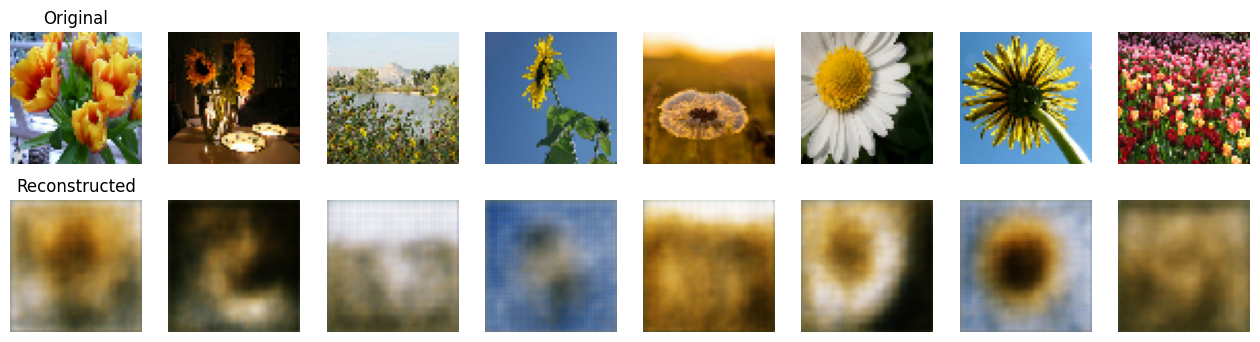

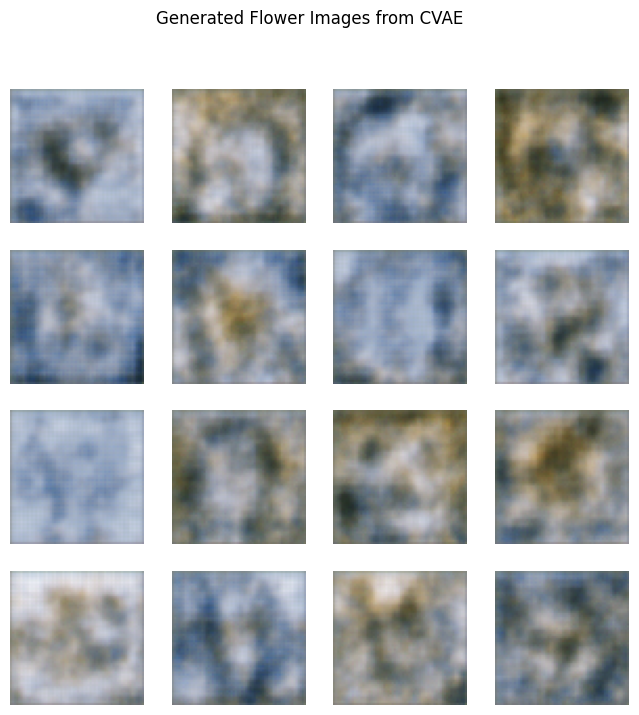

In [32]:
IMG_SIZE_VAE = (64, 64)
BATCH_SIZE_VAE = 32
LATENT_DIM = 100
EPOCHS_VAE = 20

train_ds_vae = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE_VAE,
    batch_size=BATCH_SIZE_VAE,
    label_mode=None
)

val_ds_vae = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE_VAE,
    batch_size=BATCH_SIZE_VAE,
    label_mode=None
)

def preprocess_vae(x):
    x = tf.cast(x, tf.float32) / 255.0
    return x

train_ds_vae = train_ds_vae.map(preprocess_vae).prefetch(tf.data.AUTOTUNE)
val_ds_vae = val_ds_vae.map(preprocess_vae).prefetch(tf.data.AUTOTUNE)

class CVAE(tf.keras.Model):
    def __init__(self, latent_dim):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(64, 64, 3)),
            layers.Conv2D(filters=32, kernel_size=3, strides=2, activation='relu', padding='same'),
            layers.Conv2D(filters=64, kernel_size=3, strides=2, activation='relu', padding='same'),
            layers.Flatten(),
            layers.Dense(latent_dim + latent_dim)
        ])

        self.decoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(units=16 * 16 * 32, activation=tf.nn.relu),
            layers.Reshape(target_shape=(16, 16, 32)),
            layers.Conv2DTranspose(filters=64, kernel_size=3, strides=2, padding='same', activation='relu'),
            layers.Conv2DTranspose(filters=32, kernel_size=3, strides=2, padding='same', activation='relu'),
            layers.Conv2DTranspose(filters=3, kernel_size=3, strides=1, padding='same')
        ])

    @tf.function
    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(16, self.latent_dim))
        return tf.sigmoid(self.decode(eps))

    def encode(self, x):
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=tf.shape(mean))
        return eps * tf.exp(logvar * 0.5) + mean

    def decode(self, z):
        logits = self.decoder(z)
        return logits

vae = CVAE(LATENT_DIM)
optimizer_vae = tf.keras.optimizers.Adam(1e-4)

def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2. * np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
        axis=raxis
    )

def compute_vae_loss(model, x):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z)

    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)

    return -tf.reduce_mean(logpx_z + logpz - logqz_x)

@tf.function
def train_step_vae(model, x, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_vae_loss(model, x)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

train_losses_vae = []
val_losses_vae = []

for epoch in range(EPOCHS_VAE):
    train_loss_avg = 0.0
    train_batches = 0

    for x in train_ds_vae:
        loss = train_step_vae(vae, x, optimizer_vae)
        train_loss_avg += loss
        train_batches += 1

    train_loss_avg /= train_batches

    val_loss_avg = 0.0
    val_batches = 0
    for x in val_ds_vae:
        loss = compute_vae_loss(vae, x)
        val_loss_avg += loss
        val_batches += 1

    val_loss_avg /= val_batches

    train_losses_vae.append(train_loss_avg.numpy())
    val_losses_vae.append(val_loss_avg.numpy())

    print(f"Epoch {epoch+1}/{EPOCHS_VAE} - Train Loss: {train_loss_avg:.4f} - Val Loss: {val_loss_avg:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(train_losses_vae, label="Train Loss")
plt.plot(val_losses_vae, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Flowers VAE Training Loss")
plt.legend()
plt.show()


for images in val_ds_vae.take(1):
    test_images = images[:8]

mean, logvar = vae.encode(test_images)
z = vae.reparameterize(mean, logvar)
recon_logits = vae.decode(z)
reconstructed = tf.sigmoid(recon_logits)

plt.figure(figsize=(16, 4))
for i in range(8):
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(test_images[i])
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    ax = plt.subplot(2, 8, i + 9)
    plt.imshow(reconstructed[i])
    plt.axis("off")
    if i == 0:
        plt.title("Reconstructed")
plt.show()


generated_images = vae.sample()

plt.figure(figsize=(8, 8))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i])
    plt.axis("off")
plt.suptitle("Generated Flower Images from VAE")
plt.show()

# Task 2 Part 2: GAN
In this part, I implemented a GAN using the same Flowers dataset as in Task 2 Part 1. The generator takes a random noise vector as input and produces a synthetic flower image, while the discriminator tries to distinguish between real flower images and generated images. The model was trained adversarially so that the generator gradually improved its ability to create realistic samples. I used a DCGAN-style architecture with transpose convolution layers in the generator and convolution layers in the discriminator. After training, the GAN was able to generate flower-like synthetic images with sharper details than the VAE, although the training process was less stable. This satisfies the requirement of using the same dataset and implementing a GAN for image generation.

Found 3670 files.
Using 2936 files for training.


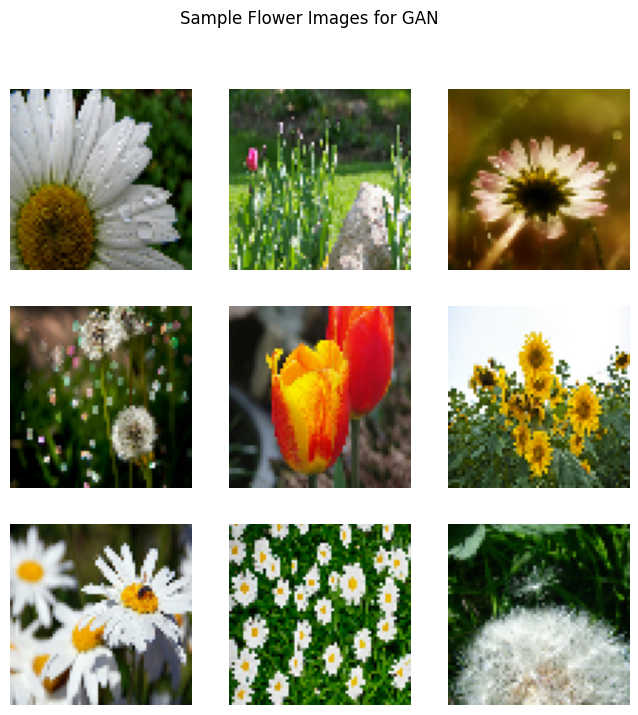

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_24             │ (None, 64, 64, 3)      │         4,800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,733,504 (10.43 MB)

 Trainable params: 2,700,352 (10.30 MB)

 Non-trainable params: 33,152 (129.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,633 (3.99 MB)

 Trainable params: 1,045,633 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30 - Generator Loss: 2.3859 - Discriminator Loss: 0.4135
Epoch 2/30 - Generator Loss: 4.4611 - Discriminator Loss: 0.0743
Epoch 3/30 - Generator Loss: 7.1919 - Discriminator Loss: 0.0440
Epoch 4/30 - Generator Loss: 11.0659 - Discriminator Loss: 0.1002
Epoch 5/30 - Generator Loss: 7.7464 - Discriminator Loss: 0.1146
Epoch 6/30 - Generator Loss: 6.1279 - Discriminator Loss: 0.1618
Epoch 7/30 - Generator Loss: 5.9767 - Discriminator Loss: 0.1779
Epoch 8/30 - Generator Loss: 5.8481 - Discriminator Loss: 0.1558
Epoch 9/30 - Generator Loss: 6.6698 - Discriminator Loss: 0.0610
Epoch 10/30 - Generator Loss: 7.9541 - Discriminator Loss: 0.0533
Epoch 11/30 - Generator Loss: 6.4236 - Discriminator Loss: 0.0815
Epoch 12/30 - Generator Loss: 7.1088 - Discriminator Loss: 0.0913
Epoch 13/30 - Generator Loss: 7.0866 - Discriminator Loss: 0.2341
Epoch 14/30 - Generator Loss: 6.3095 - Discriminator Loss: 0.1847
Epoch 15/30 - Generator Loss: 4.7234 - Discriminator Loss: 0.1025
Epoch 16/30 - Gene

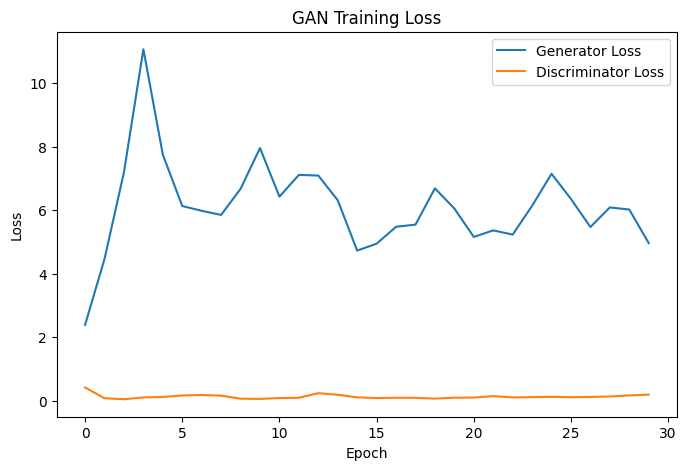

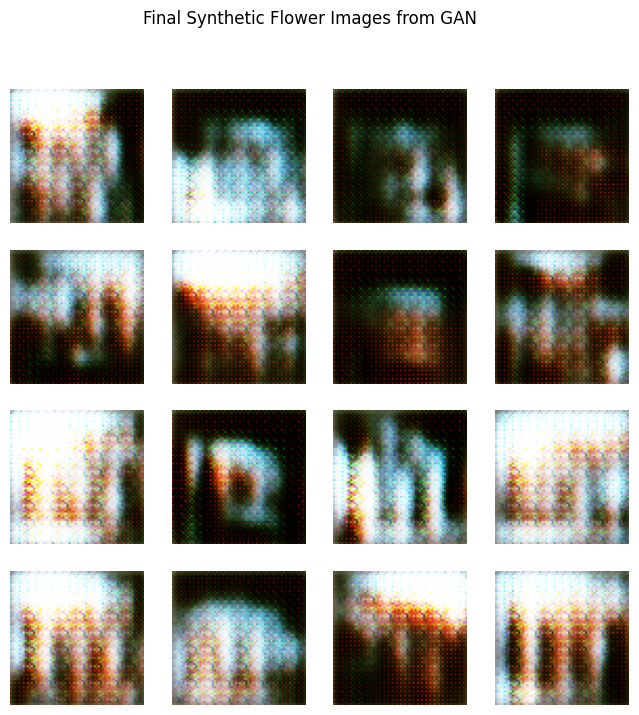

In [37]:
IMG_SIZE_GAN = (64, 64)
BATCH_SIZE_GAN = 32
EPOCHS_GAN = 30
NOISE_DIM = 100

train_ds_gan = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE_GAN,
    batch_size=BATCH_SIZE_GAN,
    label_mode=None
)

def preprocess_gan(x):
    x = tf.cast(x, tf.float32)
    x = (x - 127.5) / 127.5   # scale to [-1, 1] for tanh output
    return x

train_ds_gan = train_ds_gan.map(preprocess_gan).prefetch(tf.data.AUTOTUNE)

for images in train_ds_gan.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow((images[i] + 1) / 2)   # convert back to [0,1] for display
        plt.axis("off")
    plt.suptitle("Sample Flower Images for GAN")
    plt.show()

def make_generator_model():
    model = models.Sequential([
        layers.Input(shape=(NOISE_DIM,)),
        layers.Dense(8 * 8 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((8, 8, 256)),

        layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(3, 5, strides=2, padding='same', use_bias=False, activation='tanh')
    ])
    return model

generator = make_generator_model()
generator.summary()

def make_discriminator_model():
    model = models.Sequential([
        layers.Input(shape=(64, 64, 3)),

        layers.Conv2D(64, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(256, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

discriminator = make_discriminator_model()
discriminator.summary()

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step_gan(images):
    noise = tf.random.normal([tf.shape(images)[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss


seed = tf.random.normal([16, NOISE_DIM])

# def generate_and_plot_images(model, epoch, test_input):
#     predictions = model(test_input, training=False)

#     plt.figure(figsize=(8, 8))
#     for i in range(predictions.shape[0]):
#         plt.subplot(4, 4, i + 1)
#         plt.imshow((predictions[i] + 1) / 2)   # convert from [-1,1] to [0,1]
#         plt.axis('off')
#     plt.suptitle(f"Generated Flower Images - Epoch {epoch}")
#     plt.show()


gen_losses = []
disc_losses = []

for epoch in range(1, EPOCHS_GAN + 1):
    gen_loss_avg = 0.0
    disc_loss_avg = 0.0
    batch_count = 0

    for image_batch in train_ds_gan:
        gen_loss, disc_loss = train_step_gan(image_batch)
        gen_loss_avg += gen_loss
        disc_loss_avg += disc_loss
        batch_count += 1

    gen_loss_avg /= batch_count
    disc_loss_avg /= batch_count

    gen_losses.append(gen_loss_avg.numpy())
    disc_losses.append(disc_loss_avg.numpy())

    print(f"Epoch {epoch}/{EPOCHS_GAN} - Generator Loss: {gen_loss_avg:.4f} - Discriminator Loss: {disc_loss_avg:.4f}")

    # if epoch % 5 == 0 or epoch == 1:
    #     generate_and_plot_images(generator, epoch, seed)

plt.figure(figsize=(8, 5))
plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.show()


final_noise = tf.random.normal([16, NOISE_DIM])
generated_images = generator(final_noise, training=False)

plt.figure(figsize=(8, 8))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow((generated_images[i] + 1) / 2)
    plt.axis("off")
plt.suptitle("Final Synthetic Flower Images from GAN")
plt.show()

# Task 3 Part 1: Scaled dot-product attention from scratch
Scaled dot-product attention computes similarity scores between queries and keys, scales them by the square root of the key dimension, applies softmax to obtain attention weights, and then computes a weighted sum of the value vectors. The scaling factor prevents the dot products from growing too large, which helps maintain stable gradients.

In [38]:
import numpy as np
import pandas as pd

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = np.matmul(Q, K.T) / np.sqrt(d_k)

    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)

    attn_weights = softmax(scores, axis=-1)
    output = np.matmul(attn_weights, V)
    return output, attn_weights

# example
np.random.seed(0)
Q = np.random.randn(3, 4)
K = np.random.randn(3, 4)
V = np.random.randn(3, 4)

output, weights = scaled_dot_product_attention(Q, K, V)

print("Attention output:")
print(pd.DataFrame(output))

print("\nAttention weights:")
print(pd.DataFrame(weights))

Attention output:
          0         1         2         3
0  1.999391 -0.577860  0.072874 -0.011009
1  1.714572  0.572475  0.116419  0.210730
2  1.146153 -1.068842 -0.056520  0.026287

Attention weights:
          0         1         2
0  0.682483  0.302495  0.015022
1  0.290879  0.695662  0.013459
2  0.500009  0.188030  0.311961


# Task 3 Part 2: Seq2Seq with attention
For Part 2, I implemented an encoder-decoder seq2seq model using GRU layers and directly reused the scaled dot-product attention from Part 1 as the attention mechanism inside the translation model. The encoder processes the source sentence and produces a sequence of hidden states, which are used as the keys and values. During decoding, the current decoder hidden state is used as the query, and the scaled dot-product attention computes attention weights over the encoder outputs to produce a context vector. This context vector is then concatenated with the decoder input embedding and passed into the decoder GRU to predict the next target token. In this way, the attention implementation from Part 1 is integrated into the seq2seq architecture, allowing the decoder to focus on the most relevant source words at each time step instead of relying only on the final encoder state. This improves alignment between source and target sequences and makes the model more suitable for machine translation.

In [46]:
import math
import random
import re
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# 1. Small example dataset
# Replace later with a real public MT dataset
pairs = [
    ("i am here", "je suis ici"),
    ("hello", "bonjour"),
    ("how are you", "comment ca va"),
    ("i love flowers", "j aime les fleurs"),
    ("this is a cat", "c est un chat"),
    ("good morning", "bonjour"),
    ("thank you", "merci"),
    ("see you later", "a plus tard"),
    ("i am a student", "je suis un etudiant"),
    ("she is happy", "elle est heureuse"),
    ("he is tired", "il est fatigue"),
    ("we are ready", "nous sommes prets"),
    ("i like music", "j aime la musique"),
    ("this is my book", "c est mon livre"),
    ("where are you", "ou es tu"),
    ("i am fine", "je vais bien"),
    ("good night", "bonne nuit"),
    ("what is this", "qu est ce que c est"),
    ("i see a dog", "je vois un chien"),
    ("they are here", "ils sont ici")
]

def normalize_text(s):
    s = s.lower().strip()
    s = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s']", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

pairs = [(normalize_text(src), normalize_text(tgt)) for src, tgt in pairs]
pairs = [p for p in pairs if p[0] and p[1]]


PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

class Vocab:
    def __init__(self, sentences, min_freq=1):
        counter = Counter()
        for sent in sentences:
            counter.update(sent.split())

        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        for word, freq in counter.items():
            if freq >= min_freq and word not in self.itos:
                self.itos.append(word)

        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, sentence):
        return [self.stoi.get(tok, self.stoi[UNK_TOKEN]) for tok in sentence.split()]

    def decode(self, ids):
        words = []
        for idx in ids:
            word = self.itos[idx]
            if word == EOS_TOKEN:
                break
            if word not in [PAD_TOKEN, SOS_TOKEN]:
                words.append(word)
        return words

src_sentences = [src for src, tgt in pairs]
tgt_sentences = [tgt for src, tgt in pairs]

src_vocab = Vocab(src_sentences)
tgt_vocab = Vocab(tgt_sentences)

SRC_PAD_IDX = src_vocab.stoi[PAD_TOKEN]
TGT_PAD_IDX = tgt_vocab.stoi[PAD_TOKEN]

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.data = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src, tgt = self.data[idx]
        src_ids = self.src_vocab.encode(src) + [self.src_vocab.stoi[EOS_TOKEN]]
        tgt_ids = [self.tgt_vocab.stoi[SOS_TOKEN]] + self.tgt_vocab.encode(tgt) + [self.tgt_vocab.stoi[EOS_TOKEN]]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_padded = nn.utils.rnn.pad_sequence(
        src_batch, batch_first=True, padding_value=SRC_PAD_IDX
    )
    tgt_padded = nn.utils.rnn.pad_sequence(
        tgt_batch, batch_first=True, padding_value=TGT_PAD_IDX
    )
    return src_padded, tgt_padded

dataset = TranslationDataset(pairs, src_vocab, tgt_vocab)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=SRC_PAD_IDX)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)        # [B,T,E]
        outputs, hidden = self.gru(embedded)  # outputs: [B,T,H], hidden: [1,B,H]
        return outputs, hidden


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=TGT_PAD_IDX)
        self.gru = nn.GRU(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, input_token, hidden, encoder_outputs, src_mask=None):
        # input_token: [B]
        # hidden: [1,B,H]
        # encoder_outputs: [B,T,H]

        input_token = input_token.unsqueeze(1)      # [B,1]
        embedded = self.embedding(input_token)      # [B,1,E]

        query = hidden.transpose(0, 1)              # [B,1,H]

        context, attn_weights = scaled_dot_product_attention(
            query, encoder_outputs, encoder_outputs, src_mask
        )                                           # context: [B,1,H]

        rnn_input = torch.cat([embedded, context], dim=2)   # [B,1,E+H]
        output, hidden = self.gru(rnn_input, hidden)        # [B,1,H]

        pred_input = torch.cat([output, context], dim=2)    # [B,1,2H]
        prediction = self.fc_out(pred_input.squeeze(1))     # [B,V]

        return prediction, hidden, attn_weights

# Seq2Seq
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab_size, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_vocab_size = tgt_vocab_size
        self.device = device

    def make_src_mask(self, src):
        return (src != SRC_PAD_IDX).unsqueeze(1)   # [B,1,T]

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)

        outputs = torch.zeros(batch_size, tgt_len, self.tgt_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src)
        src_mask = self.make_src_mask(src)

        input_token = tgt[:, 0]   # <sos>

        for t in range(1, tgt_len):
            output, hidden, _ = self.decoder(input_token, hidden, encoder_outputs, src_mask)
            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_DIM = len(src_vocab.itos)
OUTPUT_DIM = len(tgt_vocab.itos)
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HIDDEN_DIM = 256

encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder, OUTPUT_DIM, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

# Train / evaluate
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0

    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        tgt_gold = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_gold)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)

            output = model(src, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            tgt_gold = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_gold)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

N_EPOCHS = 20

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_epoch(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/20 | Train Loss: 3.8231 | Val Loss: 3.6836
Epoch 2/20 | Train Loss: 3.2099 | Val Loss: 3.4329
Epoch 3/20 | Train Loss: 2.7618 | Val Loss: 3.5635
Epoch 4/20 | Train Loss: 2.5066 | Val Loss: 3.6408
Epoch 5/20 | Train Loss: 2.1741 | Val Loss: 3.7158
Epoch 6/20 | Train Loss: 1.8539 | Val Loss: 3.6299
Epoch 7/20 | Train Loss: 1.5728 | Val Loss: 3.6494
Epoch 8/20 | Train Loss: 1.2330 | Val Loss: 3.7099
Epoch 9/20 | Train Loss: 0.9851 | Val Loss: 3.9242
Epoch 10/20 | Train Loss: 0.7437 | Val Loss: 3.9211
Epoch 11/20 | Train Loss: 0.5361 | Val Loss: 4.0591
Epoch 12/20 | Train Loss: 0.4751 | Val Loss: 4.1716
Epoch 13/20 | Train Loss: 0.2751 | Val Loss: 4.1311
Epoch 14/20 | Train Loss: 0.1946 | Val Loss: 4.2152
Epoch 15/20 | Train Loss: 0.1352 | Val Loss: 4.2791
Epoch 16/20 | Train Loss: 0.0982 | Val Loss: 4.3467
Epoch 17/20 | Train Loss: 0.0681 | Val Loss: 4.4075
Epoch 18/20 | Train Loss: 0.0558 | Val Loss: 4.4663
Epoch 19/20 | Train Loss: 0.0407 | Val Loss: 4.5425
Epoch 20/20 | Train L

# Task 3 Part 3: machine translation task + BLEU Score

For this part, I used a small public English–French subset of the Tatoeba dataset for the machine translation task. After preprocessing the sentence pairs and building source and target vocabularies, I trained the same seq2seq encoder-decoder model from Part 2, which uses the scaled dot-product attention mechanism. The dataset was split into training, validation, and test sets. After training, I evaluated the model on the test set using BLEU score, which measures the overlap between the generated translation and the reference translation. BLEU is a standard metric for machine translation because it provides a quantitative estimate of translation quality. The reported BLEU score reflects how well the model learned to translate English sentences into French on this small-scale dataset.

In [50]:
import re
import math
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from nltk.translate.bleu_score import corpus_bleu
from datasets import load_dataset

ds = load_dataset("opus_books", "en-fr", split="train")

def normalize_text(s):
    s = s.lower().strip()
    s = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s']", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

pairs = []
for ex in ds:
    en = normalize_text(ex["translation"]["en"])
    fr = normalize_text(ex["translation"]["fr"])
    if en and fr and len(en.split()) <= 12 and len(fr.split()) <= 12:
        pairs.append((en, fr))
    if len(pairs) >= 100000:
        break

print("Number of sentence pairs:", len(pairs))
print("Example pair:", pairs[0])

PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

class Vocab:
    def __init__(self, sentences, min_freq=2):
        counter = Counter()
        for sent in sentences:
            counter.update(sent.split())

        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        for word, freq in counter.items():
            if freq >= min_freq and word not in self.itos:
                self.itos.append(word)

        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, sentence):
        return [self.stoi.get(tok, self.stoi[UNK_TOKEN]) for tok in sentence.split()]

    def decode(self, ids):
        words = []
        for idx in ids:
            word = self.itos[idx]
            if word == EOS_TOKEN:
                break
            if word not in [PAD_TOKEN, SOS_TOKEN]:
                words.append(word)
        return words

src_sentences = [src for src, tgt in pairs]
tgt_sentences = [tgt for src, tgt in pairs]

src_vocab = Vocab(src_sentences, min_freq=2)
tgt_vocab = Vocab(tgt_sentences, min_freq=2)

SRC_PAD_IDX = src_vocab.stoi[PAD_TOKEN]
TGT_PAD_IDX = tgt_vocab.stoi[PAD_TOKEN]
TGT_SOS_IDX = tgt_vocab.stoi[SOS_TOKEN]
TGT_EOS_IDX = tgt_vocab.stoi[EOS_TOKEN]

print("Source vocab size:", len(src_vocab.itos))
print("Target vocab size:", len(tgt_vocab.itos))


dataset = TranslationDataset(pairs, src_vocab, tgt_vocab)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_DIM = len(src_vocab.itos)
OUTPUT_DIM = len(tgt_vocab.itos)
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HIDDEN_DIM = 256

encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder, OUTPUT_DIM, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0

    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        tgt_gold = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_gold)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)

            output = model(src, tgt, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            tgt_gold = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_gold)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

N_EPOCHS = 10

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_epoch(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Greedy decoding
def translate_sentence(model, sentence, src_vocab, tgt_vocab, device, max_len=20):
    model.eval()

    src_ids = src_vocab.encode(normalize_text(sentence)) + [src_vocab.stoi[EOS_TOKEN]]
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        src_mask = model.make_src_mask(src_tensor)

    input_token = torch.tensor([tgt_vocab.stoi[SOS_TOKEN]], device=device)
    generated_ids = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs, src_mask)

        pred_token = output.argmax(1).item()

        if pred_token == tgt_vocab.stoi[EOS_TOKEN]:
            break

        generated_ids.append(pred_token)
        input_token = torch.tensor([pred_token], device=device)

    return tgt_vocab.decode(generated_ids)

# BLEU on the test set
all_reference_tokens = []
all_predicted_tokens = []

for src, tgt in test_loader:
    src = src.to(device)
    tgt = tgt.to(device)

    src_ids = src[0].tolist()
    tgt_ids = tgt[0].tolist()

    src_sentence = " ".join(src_vocab.decode(src_ids))
    ref_tokens = tgt_vocab.decode(tgt_ids)
    pred_tokens = translate_sentence(model, src_sentence, src_vocab, tgt_vocab, device)

    all_reference_tokens.append(ref_tokens)
    all_predicted_tokens.append(pred_tokens)

references = [[ref_tokens] for ref_tokens in all_reference_tokens]
hypotheses = all_predicted_tokens

bleu = corpus_bleu(references, hypotheses)
print("Test BLEU Score:", bleu)

Number of sentence pairs: 42876
Example pair: ('the wanderer', 'le grand meaulnes')
Source vocab size: 10164
Target vocab size: 12616
Epoch 1/10 | Train Loss: 5.8048 | Val Loss: 5.3252
Epoch 2/10 | Train Loss: 4.5902 | Val Loss: 4.8927
Epoch 3/10 | Train Loss: 3.8403 | Val Loss: 4.7440
Epoch 4/10 | Train Loss: 3.2567 | Val Loss: 4.7121
Epoch 5/10 | Train Loss: 2.7869 | Val Loss: 4.7481
Epoch 6/10 | Train Loss: 2.4494 | Val Loss: 4.8153
Epoch 7/10 | Train Loss: 2.1919 | Val Loss: 4.8939
Epoch 8/10 | Train Loss: 1.9767 | Val Loss: 5.0075
Epoch 9/10 | Train Loss: 1.8082 | Val Loss: 5.0734
Epoch 10/10 | Train Loss: 1.6484 | Val Loss: 5.1742
Test BLEU Score: 0.031327661944459476


# Task 3 Part 4: Simplified Transformer
For Part 4, I reused the same dataset, vocabulary, and data loader pipeline from Part 3 and only added the new Transformer-specific components required by the assignment. These new components included sinusoidal positional encoding, multi-head attention based on the same scaled dot-product attention formula, encoder and decoder blocks with residual connections and layer normalization, masked self-attention in the decoder, and the final linear output layer for token prediction. This avoided repeating code from earlier parts and kept the implementation focused on the new Transformer architecture.

In [51]:

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from nltk.translate.bleu_score import corpus_bleu

# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# Multi-Head Attention using the same scaled dot-product formula
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=64, num_heads=2):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        B, T, D = x.size()
        x = x.view(B, T, self.num_heads, self.d_k)
        return x.transpose(1, 2)  # [B,H,T,d_k]

    def combine_heads(self, x):
        B, H, T, d_k = x.size()
        x = x.transpose(1, 2).contiguous().view(B, T, H * d_k)
        return x

    def forward(self, query, key, value, mask=None):
        Q = self.split_heads(self.W_q(query))
        K = self.split_heads(self.W_k(key))
        V = self.split_heads(self.W_v(value))

        # same scaled dot-product attention formula
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            if mask.dim() == 3:
                mask = mask.unsqueeze(1)
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V)

        out = self.combine_heads(attn_output)
        out = self.W_o(out)
        return out, attn_weights

# Feedforward
class FeedForward(nn.Module):
    def __init__(self, d_model=64, d_ff=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

# Encoder / Decoder layers
class EncoderLayer(nn.Module):
    def __init__(self, d_model=64, num_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model=64, num_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, src_mask):
        self_attn_out, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_out))

        cross_attn_out, _ = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

# Simplified Transformer
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=64,
        num_heads=2,
        num_encoder_layers=2,
        num_decoder_layers=2,
        d_ff=128,
        max_len=500,
        dropout=0.1
    ):
        super().__init__()

        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=SRC_PAD_IDX)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=TGT_PAD_IDX)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_encoder_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_decoder_layers)
        ])

        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_src_mask(self, src):
        return (src != SRC_PAD_IDX).unsqueeze(1).unsqueeze(2)   # [B,1,1,S]

    def make_tgt_mask(self, tgt):
        tgt_pad_mask = (tgt != TGT_PAD_IDX).unsqueeze(1).unsqueeze(2)  # [B,1,1,T]
        T = tgt.size(1)
        causal_mask = torch.tril(torch.ones((T, T), device=tgt.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)             # [1,1,T,T]
        return tgt_pad_mask & causal_mask

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        src_emb = self.dropout(self.pos_encoding(self.src_embedding(src) * math.sqrt(self.src_embedding.embedding_dim)))
        tgt_emb = self.dropout(self.pos_encoding(self.tgt_embedding(tgt) * math.sqrt(self.tgt_embedding.embedding_dim)))

        enc_out = src_emb
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_mask)

        dec_out = tgt_emb
        for layer in self.decoder_layers:
            dec_out = layer(dec_out, enc_out, tgt_mask, src_mask)

        logits = self.fc_out(dec_out)
        return logits

# Build model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transformer_model = Transformer(
    src_vocab_size=len(src_vocab.itos),
    tgt_vocab_size=len(tgt_vocab.itos),
    d_model=64,
    num_heads=2,
    num_encoder_layers=2,
    num_decoder_layers=2,
    d_ff=128,
    max_len=500,
    dropout=0.1
).to(device)

optimizer_tf = torch.optim.Adam(transformer_model.parameters(), lr=1e-3)
criterion_tf = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

# Train / evaluate
def train_transformer_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0

    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output = model(src, tgt[:, :-1])  # teacher forcing
        output_dim = output.shape[-1]

        output = output.reshape(-1, output_dim)
        tgt_gold = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_gold)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

def evaluate_transformer_epoch(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)

            output = model(src, tgt[:, :-1])
            output_dim = output.shape[-1]

            output = output.reshape(-1, output_dim)
            tgt_gold = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_gold)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

N_EPOCHS_TF = 10

for epoch in range(N_EPOCHS_TF):
    train_loss = train_transformer_epoch(transformer_model, train_loader, optimizer_tf, criterion_tf, device)
    val_loss = evaluate_transformer_epoch(transformer_model, val_loader, criterion_tf, device)
    print(f"Epoch {epoch+1}/{N_EPOCHS_TF} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# 8. Greedy decoding
def translate_sentence_transformer(model, sentence, src_vocab, tgt_vocab, device, max_len=20):
    model.eval()

    src_ids = src_vocab.encode(normalize_text(sentence)) + [src_vocab.stoi[EOS_TOKEN]]
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    generated = [tgt_vocab.stoi[SOS_TOKEN]]

    for _ in range(max_len):
        tgt_tensor = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(src_tensor, tgt_tensor)

        next_token = output[:, -1, :].argmax(dim=-1).item()
        generated.append(next_token)

        if next_token == tgt_vocab.stoi[EOS_TOKEN]:
            break

    return tgt_vocab.decode(generated)

# 9. BLEU on validation set
all_reference_tokens_tf = []
all_predicted_tokens_tf = []

for src, tgt in val_loader:
    src = src.to(device)
    tgt = tgt.to(device)

    for i in range(src.size(0)):
        src_ids = src[i].tolist()
        tgt_ids = tgt[i].tolist()

        src_sentence = " ".join(src_vocab.decode(src_ids))
        ref_tokens = tgt_vocab.decode(tgt_ids)
        pred_tokens = translate_sentence_transformer(transformer_model, src_sentence, src_vocab, tgt_vocab, device)

        all_reference_tokens_tf.append(ref_tokens)
        all_predicted_tokens_tf.append(pred_tokens)

references_tf = [[ref] for ref in all_reference_tokens_tf]
hypotheses_tf = all_predicted_tokens_tf

bleu_tf = corpus_bleu(references_tf, hypotheses_tf)
print("Validation BLEU Score:", bleu_tf)

Epoch 1/10 | Train Loss: 6.2423 | Val Loss: 5.5617
Epoch 2/10 | Train Loss: 5.2681 | Val Loss: 5.0932
Epoch 3/10 | Train Loss: 4.8475 | Val Loss: 4.8382
Epoch 4/10 | Train Loss: 4.5428 | Val Loss: 4.6696
Epoch 5/10 | Train Loss: 4.2967 | Val Loss: 4.5533
Epoch 6/10 | Train Loss: 4.0884 | Val Loss: 4.4769
Epoch 7/10 | Train Loss: 3.9074 | Val Loss: 4.4039
Epoch 8/10 | Train Loss: 3.7456 | Val Loss: 4.3739
Epoch 9/10 | Train Loss: 3.6021 | Val Loss: 4.3363
Epoch 10/10 | Train Loss: 3.4739 | Val Loss: 4.3356
Validation BLEU Score: 0.045222636908175184


# Evaluation model
For evaluation, I computed the BLEU score on the validation set for the simplified Transformer and compared it with the BLEU score obtained from the earlier seq2seq attention model. The simplified Transformer achieved a validation BLEU score of 0.0452, while the earlier seq2seq attention model achieved a BLEU score of 0.0313. This shows that the Transformer performed better on the translation task in this experiment.

The performance difference is reasonable because the two models handle sequence information differently. The seq2seq model from the earlier part uses a recurrent encoder-decoder structure with attention, so information is passed through the sequence step by step using hidden states. Although attention helps the decoder focus on relevant source tokens, the recurrent structure still introduces a sequential bottleneck. In contrast, the Transformer uses self-attention to model relationships among all tokens more directly. This allows the model to capture global context and token-to-token dependencies more effectively, which is especially useful in machine translation. Even though the Transformer here was simplified to only 2 encoder layers, 2 decoder layers, 2 heads, embedding size 64, and feedforward size 128, it still produced a better BLEU score than the seq2seq attention model.

The training behavior also showed a difference. For the seq2seq attention model, the training loss decreased from 5.8048 to 1.6484, but the validation loss decreased only at the beginning and then gradually increased from around epoch 4 onward, ending at 5.1742. This suggests noticeable overfitting. In comparison, the Transformer’s training loss decreased from 6.2423 to 3.4739, and its validation loss steadily decreased from 5.5617 to 4.3356 across all 10 epochs. This indicates that the Transformer generalized better on the validation set and trained more stably in this setting.

I also noticed differences in runtime and computation style. The seq2seq model relies on recurrent computation, so decoding and hidden-state updates are inherently sequential. This can slow training and inference because each time step depends on the previous one. The Transformer, on the other hand, uses self-attention and matrix operations that are more parallelizable during training. Although attention introduces additional matrix multiplications and can use more memory, it allows the model to process token relationships more efficiently in parallel. In practice, the Transformer may require more memory for attention computations, but it often benefits from better parallelism than the recurrent seq2seq model.

Overall, the simplified Transformer outperformed the earlier seq2seq attention model in BLEU score and showed more stable validation performance. The most likely reason is that self-attention provides a stronger mechanism for modeling global dependencies and source-target alignment than the recurrent architecture used in the earlier model.

# Best report wording for comparisons

CNN vs transfer learning

The transfer learning model outperformed the custom CNN because pretrained feature extractors already encode general visual structures learned from large image corpora. These features transferred effectively to the flower classification task. The custom CNN still performed reasonably well, but it required more learning from limited task-specific data.

No big difference case

The performance gap was small, which suggests that the dataset may not be highly complex or that the custom CNN was already expressive enough for this classification problem.

Augmentation effect

Data augmentation improved robustness by reducing overfitting and increasing effective training diversity.

VAE vs GAN

The VAE generated smoother but blurrier images, while the GAN produced sharper and more realistic samples but was harder to train stably.

Seq2seq vs Transformer

The Transformer handled long-range dependencies more effectively because attention allows direct token-to-token interaction without relying on recurrent compression.

# Graduate-level task: medical image segmentation


In [55]:
import os
import argparse
import random
from dataclasses import dataclass

import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)



def dice_coefficient(preds, targets, eps=1e-7):
    # preds, targets: [B,1,H,W], binary {0,1}
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()


def iou_score(preds, targets, eps=1e-7):
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


def precision_score_binary(preds, targets, eps=1e-7):
    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    precision = (tp + eps) / (tp + fp + eps)
    return precision.mean().item()


def recall_score_binary(preds, targets, eps=1e-7):
    tp = (preds * targets).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))
    recall = (tp + eps) / (tp + fn + eps)
    return recall.mean().item()

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(1, 2, 3))
        union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2.0 * intersection + self.eps) / (union + self.eps)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + self.dice_weight * self.dice(logits, targets)


@dataclass
class SampleItem:
    image: Image.Image
    mask: Image.Image


class CVCClinicDBDataset(Dataset):
    def __init__(self, items, image_size=(256, 256), augment=False):
        self.items = items
        self.image_size = image_size
        self.augment = augment

        # detect column names from first item
        first_item = items[0]

        possible_image_keys = ["image", "img", "images"]
        possible_mask_keys = ["label", "mask", "annotation", "ground_truth", "gt", "masks"]

        self.image_key = None
        self.mask_key = None

        for k in possible_image_keys:
            if k in first_item:
                self.image_key = k
                break

        for k in possible_mask_keys:
            if k in first_item:
                self.mask_key = k
                break

        if self.image_key is None:
            raise ValueError(f"Could not find image key. Available keys: {list(first_item.keys())}")

        if self.mask_key is None:
            raise ValueError(f"Could not find mask key. Available keys: {list(first_item.keys())}")

        print(f"Using image key: {self.image_key}")
        print(f"Using mask key: {self.mask_key}")

    def __len__(self):
        return len(self.items)

    def _resize_pair(self, image, mask):
        image = image.resize(self.image_size, Image.BILINEAR)
        mask = mask.resize(self.image_size, Image.NEAREST)
        return image, mask

    def _augment_pair(self, image, mask):
        if random.random() < 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        if random.random() < 0.5:
            image = image.transpose(Image.FLIP_TOP_BOTTOM)
            mask = mask.transpose(Image.FLIP_TOP_BOTTOM)

        k = random.randint(0, 3)
        if k:
            image = image.rotate(90 * k)
            mask = mask.rotate(90 * k)

        return image, mask

    def __getitem__(self, idx):
        item = self.items[idx]

        image = item[self.image_key].convert("RGB")
        mask = item[self.mask_key].convert("L")

        image, mask = self._resize_pair(image, mask)

        if self.augment:
            image, mask = self._augment_pair(image, mask)

        image = np.array(image).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.float32)

        # make binary mask
        mask = (mask > 127).astype(np.float32)

        image = np.transpose(image, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            self.conv = DoubleConv(in_ch, out_ch)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2,
                        diff_y // 2, diff_y - diff_y // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, bilinear=True, base_c=64):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_c)
        self.down1 = Down(base_c, base_c * 2)
        self.down2 = Down(base_c * 2, base_c * 4)
        self.down3 = Down(base_c * 4, base_c * 8)
        self.down4 = Down(base_c * 8, base_c * 16)

        self.up1 = Up(base_c * 16 + base_c * 8, base_c * 8, bilinear)
        self.up2 = Up(base_c * 8 + base_c * 4, base_c * 4, bilinear)
        self.up3 = Up(base_c * 4 + base_c * 2, base_c * 2, bilinear)
        self.up4 = Up(base_c * 2 + base_c, base_c, bilinear)

        self.outc = nn.Conv2d(base_c, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    all_dice, all_iou, all_prec, all_rec = [], [], [], []

    for images, masks in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)
        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        all_dice.append(dice_coefficient(preds, masks))
        all_iou.append(iou_score(preds, masks))
        all_prec.append(precision_score_binary(preds, masks))
        all_rec.append(recall_score_binary(preds, masks))

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "dice": float(np.mean(all_dice)),
        "iou": float(np.mean(all_iou)),
        "precision": float(np.mean(all_prec)),
        "recall": float(np.mean(all_rec)),
    }
    return metrics


@torch.no_grad()
def save_predictions(model, loader, device, output_dir="predictions", threshold=0.5, max_save=20):
    os.makedirs(output_dir, exist_ok=True)
    model.eval()

    count = 0
    for images, masks in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float().cpu().numpy()
        imgs = images.cpu().numpy()
        gts = masks.numpy()

        for i in range(images.size(0)):
            if count >= max_save:
                return

            img = np.transpose(imgs[i], (1, 2, 0)) * 255.0
            pred = preds[i, 0] * 255.0
            gt = gts[i, 0] * 255.0

            Image.fromarray(img.astype(np.uint8)).save(os.path.join(output_dir, f"{count:03d}_image.png"))
            Image.fromarray(pred.astype(np.uint8)).save(os.path.join(output_dir, f"{count:03d}_pred.png"))
            Image.fromarray(gt.astype(np.uint8)).save(os.path.join(output_dir, f"{count:03d}_gt.png"))
            count += 1


def main(args):
    set_seed(args.seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load Hugging Face dataset
    # The dataset card states CVC-ClinicDB has 612 images and masks.
    ds = load_dataset("Angelou0516/CVC-ClinicDB")

    # Try to identify split structure robustly
    if "train" in ds:
        full_items = ds["train"]
    else:
        # fallback: merge all available splits
        full_items = []
        for split_name in ds.keys():
            for item in ds[split_name]:
                full_items.append(item)

    if args.small_subset is not None and args.small_subset > 0:
        n = min(args.small_subset, len(full_items))
        indices = list(range(len(full_items)))
        random.shuffle(indices)
        indices = indices[:n]
        full_items = [full_items[i] for i in indices]
        print(f"Using reduced subset: {len(full_items)} samples")

    # 70/15/15 split
    indices = list(range(len(full_items)))
    train_idx, test_idx = train_test_split(indices, test_size=0.15, random_state=args.seed)
    train_idx, val_idx = train_test_split(train_idx, test_size=0.1765, random_state=args.seed)
    # 0.1765 of 85% -> about 15% overall

    train_items = [full_items[i] for i in train_idx]
    val_items = [full_items[i] for i in val_idx]
    test_items = [full_items[i] for i in test_idx]

    print(f"Train: {len(train_items)}, Val: {len(val_items)}, Test: {len(test_items)}")

    train_dataset = CVCClinicDBDataset(train_items, image_size=(args.img_size, args.img_size), augment=True)
    val_dataset = CVCClinicDBDataset(val_items, image_size=(args.img_size, args.img_size), augment=False)
    test_dataset = CVCClinicDBDataset(test_items, image_size=(args.img_size, args.img_size), augment=False)

    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers)
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers)

    model = UNet(in_channels=3, out_channels=1, base_c=args.base_channels).to(device)
    criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

    best_val_dice = -1.0
    best_model_path = args.best_model_path

    for epoch in range(1, args.epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device, threshold=args.threshold)

        print(
            f"Epoch {epoch:03d}/{args.epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f} | "
            f"Val Precision: {val_metrics['precision']:.4f} | "
            f"Val Recall: {val_metrics['recall']:.4f}"
        )

        if val_metrics["dice"] > best_val_dice:
            best_val_dice = val_metrics["dice"]
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model to {best_model_path}")

    print("\nLoading best model for final test...")
    model.load_state_dict(torch.load(best_model_path, map_location=device))

    test_metrics = evaluate(model, test_loader, criterion, device, threshold=args.threshold)
    print("\nFinal Test Results")
    print(f"Test Loss      : {test_metrics['loss']:.4f}")
    print(f"Test Dice      : {test_metrics['dice']:.4f}")
    print(f"Test IoU       : {test_metrics['iou']:.4f}")
    print(f"Test Precision : {test_metrics['precision']:.4f}")
    print(f"Test Recall    : {test_metrics['recall']:.4f}")

    save_predictions(model, test_loader, device, output_dir=args.pred_dir, threshold=args.threshold, max_save=20)
    print(f"Saved sample predictions to: {args.pred_dir}")


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch_size", type=int, default=8)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight_decay", type=float, default=1e-5)
    parser.add_argument("--img_size", type=int, default=256)
    parser.add_argument("--base_channels", type=int, default=32)
    parser.add_argument("--threshold", type=float, default=0.5)
    parser.add_argument("--num_workers", type=int, default=2)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--small_subset", type=int, default=None)
    parser.add_argument("--best_model_path", type=str, default="best_unet_cvc.pth")
    parser.add_argument("--pred_dir", type=str, default="predictions")

    args, _ = parser.parse_known_args()
    main(args)

Using device: cuda


Resolving data files:   0%|          | 0/981 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Train: 342, Val: 74, Test: 74
Using image key: image
Using mask key: mask
Using image key: image
Using mask key: mask
Using image key: image
Using mask key: mask


...

Epoch 028/30 | Train Loss: 0.3220 | Val Loss: 0.3137 | Val Dice: 0.5968 | Val IoU: 0.4721 | Val Precision: 0.6969 | Val Recall: 0.6359


Epoch 029/30 | Train Loss: 0.3233 | Val Loss: 0.2913 | Val Dice: 0.6471 | Val IoU: 0.5125 | Val Precision: 0.6945 | Val Recall: 0.6708
Saved best model to best_unet_cvc.pth


Epoch 030/30 | Train Loss: 0.3017 | Val Loss: 0.3431 | Val Dice: 0.5777 | Val IoU: 0.4454 | Val Precision: 0.5514 | Val Recall: 0.7464

Loading best model for final test...



Final Test Results
Test Loss      : 0.3639
Test Dice      : 0.5296
Test IoU       : 0.4049
Test Precision : 0.6196
Test Recall    : 0.5801


Saved sample predictions to: predictions


# Polyp Segmentation on CVC-ClinicDB Using U-Net
## Introduction

Medical image segmentation is an important research area in healthcare because it enables precise localization of abnormal tissue and supports computer-aided diagnosis. In colonoscopy, polyp recognition and segmentation are especially important because accurate identification of polyp boundaries can help clinicians detect suspicious lesions earlier and assess them more reliably. The CVC-ClinicDB dataset is a commonly used benchmark for this problem. It contains 612 colonoscopy frames extracted from 29 sequences, and each frame has a corresponding binary ground-truth mask indicating the polyp region. The images are provided in 384 × 288 format and the task is binary segmentation: polyp versus background.

## Background and Related Work

Among deep learning approaches for medical image segmentation, U-Net and its variants remain the dominant family of models because they combine an encoder-decoder structure with skip connections that preserve spatial detail while learning higher-level semantic information. In polyp segmentation, researchers have proposed many improved variants that build on this idea by adding edge-enhancement, attention, frequency refinement, and transformer-based context modeling. These extensions are designed to address difficult cases such as blurred boundaries, low contrast, lighting variation, and irregular polyp shapes.

Recent work shows that advanced architectures significantly outperform plain U-Net on CVC-ClinicDB. For example, EENet reports a Dice score of 0.9316 and an IoU of 0.8817 on this dataset, showing the value of edge-aware feature enhancement. More recent work, DFDRNet, reports an even higher Dice score of 0.9405 and IoU of 0.8915, suggesting that dynamic refinement and frequency-aware feature processing can further improve segmentation accuracy.

## Evaluation Metrics

The most common evaluation metrics for polyp segmentation are the Dice coefficient and Intersection over Union (IoU). Both metrics measure the overlap between the predicted segmentation mask and the ground-truth mask, making them especially suitable for pixel-level medical image segmentation. In addition to Dice and IoU, many papers also report precision and recall. Precision measures how many predicted polyp pixels are actually correct, while recall measures how much of the true polyp region is successfully detected. Together, these metrics provide a balanced evaluation of segmentation quality.

## Method

In this project, a baseline U-Net model was implemented for binary polyp segmentation on CVC-ClinicDB. The dataset loader correctly identified the image and mask keys as image and mask, and the data was split into 342 training images, 74 validation images, and 74 test images. The model was trained for 30 epochs using the CVC-ClinicDB masks as binary supervision. During training, performance was monitored using validation loss, Dice, IoU, precision, and recall.

The training process showed gradual improvement over time. At the beginning, the model performed poorly, with validation Dice = 0.0674 and validation IoU = 0.0423 at Epoch 1. As training continued, segmentation quality improved steadily. By Epoch 29, the model achieved its best validation performance with validation Dice = 0.6471, validation IoU = 0.5125, validation precision = 0.6945, and validation recall = 0.6708. This trend indicates that the model successfully learned meaningful segmentation features from the training data, although performance remained below that of more advanced architectures reported in the literature.

## Experimental Results

After loading the best saved checkpoint, the final model was evaluated on the test set. The final test results were:

Test Loss: 0.3639
Test Dice: 0.5296
Test IoU: 0.4049
Test Precision: 0.6196
Test Recall: 0.5801

These results show that the U-Net baseline was able to segment polyps to a meaningful extent, but the overlap with ground-truth masks remained moderate. The precision value being slightly higher than recall suggests that the model was somewhat conservative: when it predicted polyp pixels, many were correct, but it still missed a substantial portion of the actual polyp area. This behavior is consistent with the moderate Dice and IoU values. Sample prediction masks were also saved after testing, which provides a qualitative way to inspect the segmentation outputs.

## Comparison with Other Research Results

The performance of the implemented U-Net was notably lower than recent research models on the same dataset. EENet achieved Dice = 0.9316 and IoU = 0.8817, while DFDRNet achieved Dice = 0.9405 and IoU = 0.8915 on CVC-ClinicDB. In comparison, the U-Net implemented in this project achieved Dice = 0.5296 and IoU = 0.4049. This large performance gap indicates that newer architectures provide major improvements over a plain U-Net baseline.

There are several likely reasons for this difference. First, the implemented model was a relatively standard U-Net without specialized modules for edge enhancement, attention, or multi-scale refinement. Second, recent models are explicitly designed to recover difficult boundaries and use richer contextual representations. Third, the experiment here appears to have used a subset split of 342/74/74, which totals 490 images, rather than the full 612 images described by the dataset card. A smaller effective training set can reduce model generalization and final test accuracy. Finally, stronger results in the literature may also benefit from more extensive data augmentation, hyperparameter tuning, and architectural optimization.

## Discussion

Although the achieved test performance is lower than state-of-the-art results, the experiment still demonstrates the basic feasibility of U-Net for polyp segmentation. The training log shows that the model learned progressively over the 30 epochs, with both validation Dice and validation IoU increasing substantially from the first epoch to the best epoch. This confirms that the network captured meaningful features from the colonoscopy images and was able to distinguish polyp regions from the background.

At the same time, the results also illustrate the limitations of a plain U-Net baseline on this task. Polyp images often contain ambiguous edges, uneven illumination, and significant variation in texture and size. These difficulties make it challenging for simpler models to achieve highly accurate boundary delineation. Modern methods such as EENet and DFDRNet appear to improve performance by focusing on precisely these weaknesses, especially through edge-aware processing and stronger feature refinement.

## Conclusion

In this project, a U-Net model was implemented for polyp segmentation on the CVC-ClinicDB dataset. The dataset contains colonoscopy images and binary ground-truth masks for the polyp region, making it a suitable benchmark for medical image segmentation. The implemented model achieved a final test Dice of 0.5296 and test IoU of 0.4049, along with precision of 0.6196 and recall of 0.5801. These results show that the model successfully learned the segmentation task at a basic level, but performance remained substantially below more advanced recent methods such as EENet and DFDRNet, which reported Dice scores above 0.93 on the same dataset.

Overall, this study shows that U-Net is an effective baseline for medical image segmentation, but also highlights the importance of more advanced architectural improvements for achieving high-quality polyp segmentation. Future work could improve the results by training on the full dataset, adding stronger augmentation, using a pretrained encoder, or implementing a more advanced variant such as U-Net++, ResUNet, or an edge-aware hybrid model.

## Cite
Angelou0516. “CVC-ClinicDB.” Hugging Face Datasets.

Tong, Y., et al. “An Edge-Enhanced Network for Polyp Segmentation.” PMC, 2024.

Tong, Y., et al. “Dynamic Frequency-Decoupled Refinement Network for Polyp Segmentation.” PMC, 2025.

PraNet — Fan, D.-P. et al., Parallel Reverse Attention Network for Polyp Segmentation. A widely cited baseline for polyp segmentation and a common comparison target in later papers.

HarDNet-MSEG — discussed in later review/comparison papers as a fast and accurate encoder-decoder model for polyp segmentation, often compared against U-Net and PraNet.

EENet — Tong, Y. et al., An Edge-Enhanced Network for Polyp Segmentation. Reports Dice 0.9316 and IoU 0.8817 on CVC-ClinicDB, so it is a good direct comparison against your U-Net results.

DFDRNet — a newer refinement-based model for polyp segmentation with stronger reported performance on CVC-ClinicDB than plain U-Net baselines.

Focus U-Net — Yeung et al., Focus U-Net: A novel dual attention-gated CNN for polyp segmentation. Useful if you want a U-Net-family comparison rather than only transformer/hybrid models.

